In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df_diabetes = pd.read_csv("./diabetes.csv")
df_diabetes.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148,72.0,35.0,0.0,33.6,0.627,50,1
1,1,1,85,66.0,29.0,0.0,26.6,0.351,31,0
2,2,8,183,64.0,0.0,0.0,23.3,0.672,32,1
3,3,1,89,66.0,23.0,94.0,28.1,0.167,21,0
4,4,0,137,40.0,35.0,168.0,43.1,2.288,33,1


In [15]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             767 non-null    float64
 4   SkinThickness             756 non-null    float64
 5   Insulin                   763 non-null    float64
 6   BMI                       767 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
 9   Outcome                   768 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 60.1 KB


In [16]:
df_diabetes.describe()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,767.000000,756.000000,763.000000,767.000000,768.000000,768.000000,768.000000
mean,383.500000,3.845052,120.894531,69.195567,20.862434,80.322412,32.034289,0.471876,33.240885,0.348958
std,221.846794,3.369578,31.972618,19.206609,15.865314,115.439459,7.804050,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,191.750000,1.000000,99.000000,63.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,383.500000,3.000000,117.000000,72.000000,23.000000,36.000000,32.000000,0.372500,29.000000,0.000000
75%,575.250000,6.000000,140.250000,80.000000,32.000000,128.500000,36.600000,0.626250,41.000000,1.000000
max,767.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


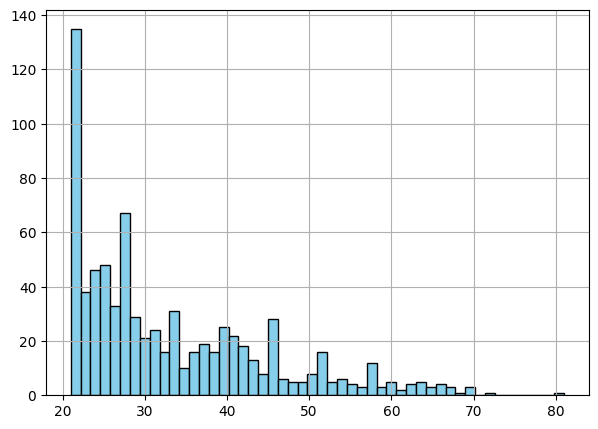

In [17]:
_ = df_diabetes["Age"].hist(bins=50, color='skyblue', edgecolor='k', figsize=(7,5))


- **Categoría 1:** `age_cat = 1` → ingresos entre **21 y 30**. 
- **Categoría 2:** `age_cat = 2` → ingresos entre **30 y 40**.  
- **Categoría 3:** `age_cat = 3` → ingresos entre **40 y 50**.  
- **Categoría 4:** `age_cat = 4` → ingresos entre **50 y 60**.  
- **Categoría 5:** `age_cat = 5` → ingresos **mayores a 60**.  

In [18]:
df_diabetes["age_cat"] = pd.cut(df_diabetes["Age"], bins=[20, 30, 40, 50, 60, np.inf], labels=[1, 2, 3, 4, 5])
df_diabetes.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,age_cat
0,0,6,148,72.0,35.0,0.0,33.6,0.627,50,1,3
1,1,1,85,66.0,29.0,0.0,26.6,0.351,31,0,2
2,2,8,183,64.0,0.0,0.0,23.3,0.672,32,1,2
3,3,1,89,66.0,23.0,94.0,28.1,0.167,21,0,1
4,4,0,137,40.0,35.0,168.0,43.1,2.288,33,1,2


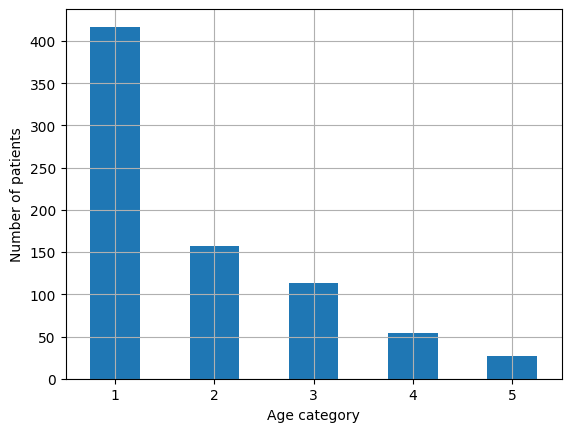

In [19]:
df_diabetes["age_cat"].value_counts().sort_index().plot.bar(rot=0)
plt.xlabel("Age category")
plt.ylabel("Number of patients")
_ = plt.grid()

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_diabetes, test_size=0.065, stratify=df_diabetes["age_cat"], random_state=42)

In [22]:
# Eliminamos la categoria age_cat de ambos conjuntos porque no la usamos más
for set_ in (train_set, test_set):
    set_.drop("age_cat", axis=1, inplace=True)